<a href="https://colab.research.google.com/github/kithik7/Theoretical_Neuroscience/blob/TNS1_Ex6_ConditionalProb_SignalDetectionTheory/TNS_I_Exercise_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Conditional probability and signal-detection theory

## Introduction
You will characterise the noisy responses of a sensory neuron to stimuli of two types and of different strengths. You will compute the conditional probability of responses given a stimulus type, determine how informative response are about stimulus type, and compute the conditional likelihood of stimulus types given a response.


## Sensory stimuli and responses

Generate a sequence of stimuli of different strength and type.  Randomly assign to each stimulus one of two types, $A$ or $B$.  Additionally, assign to all stimulus a fixed strength, $s$.  Specifically, create an input matrix with 2 rows (for the two types) and $n$ columns (for a sequence of length $n$):  

$$
S_{in} =
\begin{pmatrix}
 0 & s & s & 0 & \ldots & s & 0 \\ s & 0 & 0 & s & \ldots & 0 & s
\end{pmatrix}
$$

\\
The non-zero stimuli in the top row are of type $A$ and the non-zero stimuli in the bottom row of type $B$.


You are provided with the function ```SensResp()``` which produces a variable response $x$ to stimulus sequences in this format.


When supplied with above input $S_{in}$, ```SensResp()``` produces a vector of responses

$$
R_{out} = \begin{pmatrix} r_1 & r_2 & r_3 & r_4 & \ldots & r_{n-1} & r_n \end{pmatrix}
$$

of size $[1,n]$

## Assignment I: Conditional response probability
Stimulate repeatedly (at least 500 times) with stimuli $A$ and $B$ of strength $s=2$. Obtain a histogram of the fractional probability of different size responses. Plot the conditional response probability $P(x | A)$ for stimulus $A$ and, separately,  the conditional response probability $P( x | B)$!

Repeat for stimuli of strength $s=7$ and strength $s=20$!

Discuss your results!  How well do the responses distinguish between the two stimuli for different values of $s$?

## Assignment II: ROC analysis
Quantify the informativeness of the neuron's responses about stimulus type for $s=20$!  Specifically, perform an ROC analysis by placing a decision criterion at different response levels, covering the entire range from the smallest to the largest responses.  For each criterion levels, compute the fraction of responses above that level  in $P(x | A)$ and, separately, in $P(x | B)$. Plot the fraction above in the $A$-distribution against the fraction above in the $B$-distribution, for all criterion levels. Compute the area under the resulting curve, as a fraction of the entire plot area!  This is the reliability (fraction correct) with which stimulus type ($A$ or $B$) can be inferred from the neurone's response at $s=20$.


## Assignment III: Stimulus likelihood
In the previous assignment, you obtained the conditional probabilities $P(x|A)$ and $P(x|B)$ for stimulus strength $s=20$.  Building on these results,
obtain the marginal probability $P(x)$ assuming $P(A) = P(B) = 0.5$, as follows

\\
$$
P(x) = \frac{1}{2} \, P(x|A) +  \frac{1}{2} \, P(x|B)
$$

Finally, apply Bayes' rule to obtain the conditional likelihoods $L(A|x)$ and $L(B|x)$, as follows

\\
$$
L(A|x) = \frac{P(x|A) \cdot P(A)}{P(x)}, \qquad\qquad L(B|x) = \frac{P(x|B) \cdot P(B)}{P(x)}
$$


Plot $L(A|x)$ and $L(B|x)$ as a function of observed response $x$ in the same plot!  Discuss your results!




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

def sens_resp(stim_strength: int, stim_type: str) -> np.ndarray:
    """
    This function generates response from a neuron based on two types of
    stimuli, either A or B, as well as the strength of those stimuli (1-40).
    """

    if stim_type == "A":
        Sin = np.tile(np.vstack([stim_strength, 0]), (1, 50000))
    elif stim_type == "B":
        Sin = np.tile(np.vstack([0, stim_strength]), (1, 50000))

    # Adjust rows based on the condition
    kk = np.where(Sin[0, :] >= Sin[1, :])[0]
    Sin[1, kk] = 0
    ll = np.where(Sin[0, :] < Sin[1, :])[0]
    Sin[0, ll] = 0

    # Constants
    SA = 5
    SB = 10
    Rmax = 20
    Rdark = 1
    m = Sin.shape[1]
    # Initialise
    Rout = np.full(m, np.nan)

    # Compute Rout for non-zero elements
    kk = np.where(Sin[0, :] != 0)[0]
    if kk.size > 0:
        Sin2 = Sin[0, kk] ** 2
        Rout[kk] = Rdark + Rmax * Sin2 / (SA ** 2 + Sin2)

    # Compute Rout for non-zero elements
    ll = np.where(Sin[1, :] != 0)[0]
    if ll.size > 0:
        Sin2 = Sin[1, ll] ** 2
        Rout[ll] = Rdark + Rmax * Sin2 / (SB ** 2 + Sin2)

    # Generate Poisson distributed output based on Rout
    xrand = np.random.rand(m)
    Xout = poisson.ppf(xrand, Rout)

    return Xout.astype(int) # Cast each value to int


In [ ]:
# Example usage of the function sens_resp(). Supply the stimulus strength
# as well as the stimulus type, either A or B.

sens_resp(1, "A")


array([1, 0, 0, ..., 3, 2, 0])

In [ ]:
nRepeats = 500

def stimulateResponse(strength, repeats):
  # create a vector for response A ('present') and a vector for response B ('absent)
  stimAVector = []
  stimBVector = []
  for n in range(repeats):
    stimA = sens_resp(strength, "A")
    stimB = sens_resp(strength, "B")
    stimAVector.append(stimA)
    stimBVector.append(stimB)
  # convert 2D vectors into 1D vectors
  stimAVector = np.hstack(stimAVector)
  stimBVector = np.hstack(stimBVector)
  stimVector = []
  # output as 2D vector with A as first row, B as second row
  stimVector.append(stimAVector)
  stimVector.append(stimBVector)
  return np.array(stimVector)


In [ ]:
# stimulate with strength of 2
stimStrength = 2
x = stimulateResponse(stimStrength,nRepeats)

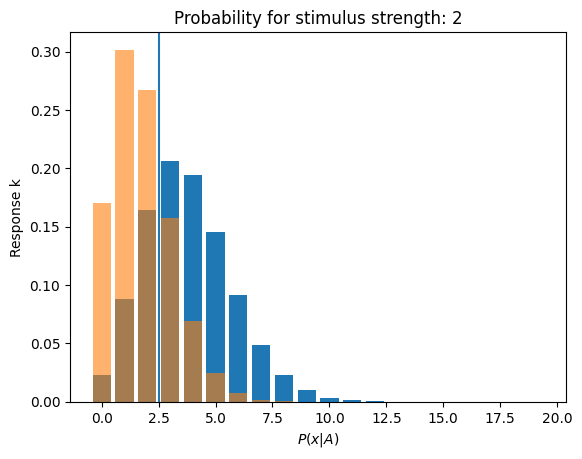

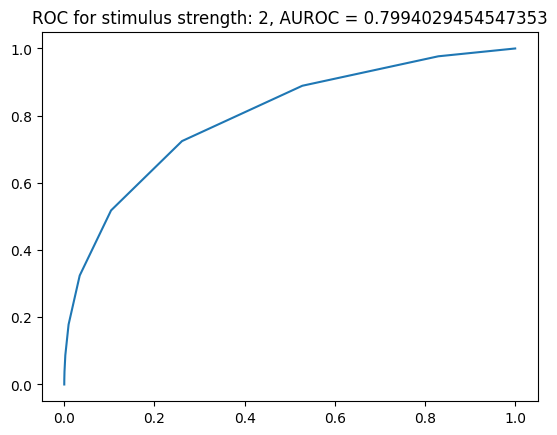

In [ ]:
nBins = 20
nStim = nRepeats * 50000
# set maximum range for histogram
maxRange = 20
# generate histogram data for A and B
histA = np.histogram(x[0,:],bins=nBins, range=[0,maxRange])
histB = np.histogram(x[1,:],bins=nBins, range=[0,maxRange])
# convert counts to probabilities
probA = histA[0]/nStim
probB = histB[0]/nStim
# plot the probabilities on the y-axis
plt.bar(histA[1][0:-1],probA, label='A')
# use alpha to make B response opaque
plt.bar(histB[1][0:-1],probB, alpha=0.6, label='B')
#plt.legend(loc='upper right')

# check accuracy of criterion
H_a_vector = []   # vector to store hits
F_p_vector = []   # vector to store false positives
crit_vector = []  # vector to store criterion results
for criterion in range(nBins):
  # calculate hits and misses
  H_a = np.sum(probA[criterion:-1])
  H_a_vector.append(H_a)
  M_a = 1 - H_a
  # calculate false positives and true negatives
  F_p = np.sum(probB[criterion:-1])
  F_p_vector.append(F_p)
  T_n = 1 - F_p
  P_corr = (H_a + 1 - F_p) /2
  crit_vector.append([criterion, P_corr])
crit_vector = np.array(crit_vector)
maxPCorr = np.max(crit_vector[:,1])
bestCrit = crit_vector[crit_vector[:,1] == maxPCorr]
plt.axvline(bestCrit[0,0]-0.5)
plt.title(f'Probability for stimulus strength: {stimStrength}')
plt.xlabel('Response k')
plt.ylabel('$P(x|A)$')
plt.show()
auc = np.trapz(H_a_vector[::-1],F_p_vector[::-1])
plt.plot(F_p_vector,H_a_vector)
plt.title(f'ROC for stimulus strength: {stimStrength}, AUROC = {auc}')
plt.show()

In [ ]:
stimStrength = 7
x = stimulateResponse(stimStrength,nRepeats)

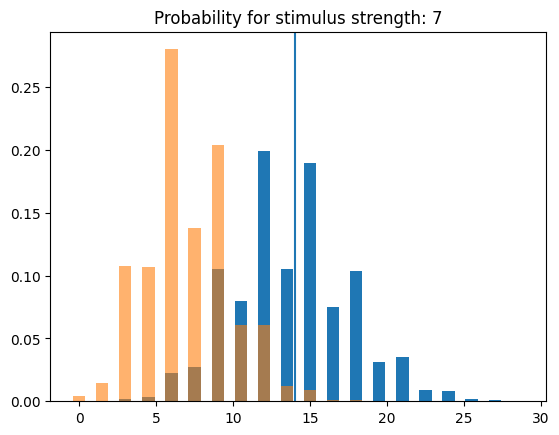

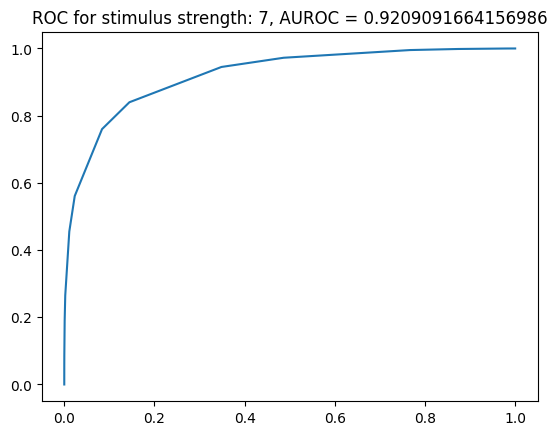

In [ ]:
# set maximum range for histogram
maxRange = 30
# generate histogram data for A and B
histA = np.histogram(x[0,:],bins=nBins, range=[0,maxRange])
histB = np.histogram(x[1,:],bins=nBins, range=[0,maxRange])
# convert counts to probabilities
probA = histA[0]/nStim
probB = histB[0]/nStim
# plot the probabilities on the y-axis
plt.bar(histA[1][0:-1],probA, label='A')
# use alpha to make B response opaque
plt.bar(histB[1][0:-1],probB, alpha=0.6, label='B')
#plt.legend(loc='upper right')

# check accuracy of criterion
H_a_vector = []   # vector to store hits
F_p_vector = []   # vector to store false positives
crit_vector = []  # vector to store criterion results
for criterion in range(nBins):
  # calculate hits and misses
  H_a = np.sum(probA[criterion:-1])
  H_a_vector.append(H_a)
  M_a = 1 - H_a
  # calculate false positives and true negatives
  F_p = np.sum(probB[criterion:-1])
  F_p_vector.append(F_p)
  T_n = 1 - F_p
  P_corr = (H_a + 1 - F_p) /2
  crit_vector.append([criterion, P_corr])
crit_vector = np.array(crit_vector)
maxPCorr = np.max(crit_vector[:,1])
histRange = np.arange(0,40,2)
bestCrit = crit_vector[crit_vector[:,1] == maxPCorr]
plt.axvline(histRange[bestCrit[0,0].astype(int)])
plt.title(f'Probability for stimulus strength: {stimStrength}')
plt.show()
auc = np.trapz(H_a_vector[::-1],F_p_vector[::-1])
plt.plot(F_p_vector,H_a_vector)
plt.title(f'ROC for stimulus strength: {stimStrength}, AUROC = {auc}')
plt.show()

In [ ]:
stimStrength = 12
x = stimulateResponse(stimStrength,nRepeats)

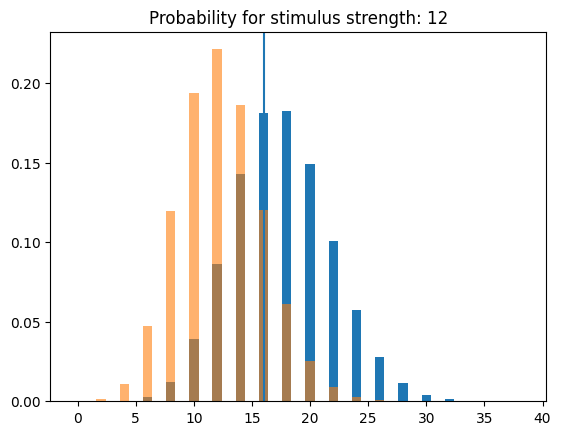

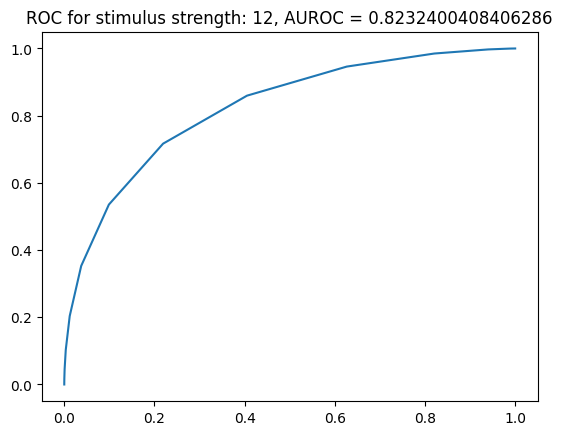

In [ ]:
# set maximum range for histogram
maxRange = 40
# generate histogram data for A and B
histA = np.histogram(x[0,:],bins=nBins, range=[0,maxRange])
histB = np.histogram(x[1,:],bins=nBins, range=[0,maxRange])
# convert counts to probabilities
probA = histA[0]/nStim
probB = histB[0]/nStim
# plot the probabilities on the y-axis
plt.bar(histA[1][0:-1],probA, label='A')
# use alpha to make B response opaque
plt.bar(histB[1][0:-1],probB, alpha=0.6, label='B')
#plt.legend(loc='upper right')

# check accuracy of criterion
H_a_vector = []   # vector to store hits
F_p_vector = []   # vector to store false positives
crit_vector = []  # vector to store criterion results
for criterion in range(nBins):
  # calculate hits and misses
  H_a = np.sum(probA[criterion:-1])
  H_a_vector.append(H_a)
  M_a = 1 - H_a
  # calculate false positives and true negatives
  F_p = np.sum(probB[criterion:-1])
  F_p_vector.append(F_p)
  T_n = 1 - F_p
  P_corr = (H_a + 1 - F_p) /2
  crit_vector.append([criterion, P_corr])
crit_vector = np.array(crit_vector)
maxPCorr = np.max(crit_vector[:,1])
histRange = np.arange(0,40,2)
bestCrit = crit_vector[crit_vector[:,1] == maxPCorr]
plt.axvline(histRange[bestCrit[0,0].astype(int)])
plt.title(f'Probability for stimulus strength: {stimStrength}')
plt.show()
auc = np.trapz(H_a_vector[::-1],F_p_vector[::-1])
plt.plot(F_p_vector,H_a_vector)
plt.title(f'ROC for stimulus strength: {stimStrength}, AUROC = {auc}')
plt.show()

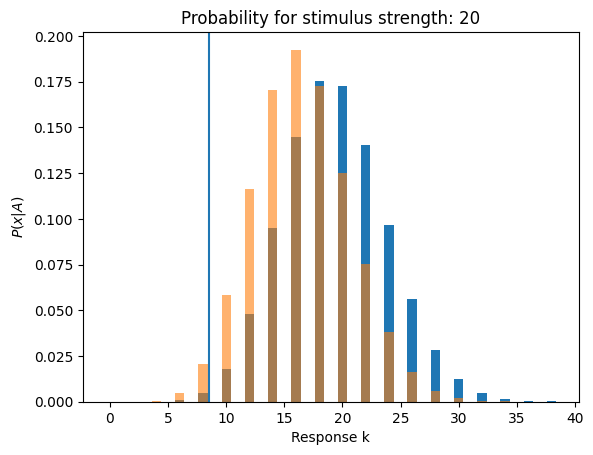

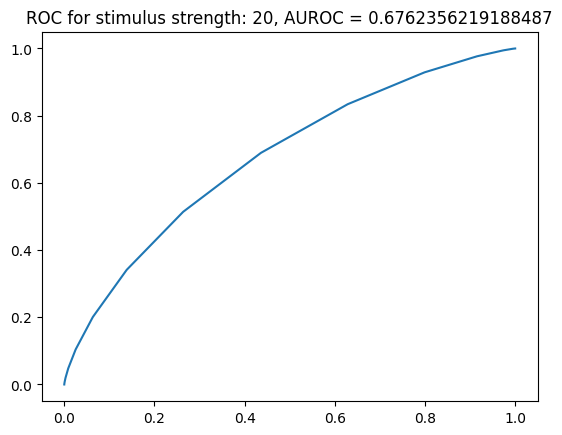

In [ ]:
stimStrength = 20
x = stimulateResponse(stimStrength,nRepeats)
# set maximum range for histogram
maxRange = 40
# generate histogram data for A and B
histA = np.histogram(x[0,:],bins=nBins, range=[0,maxRange])
histB = np.histogram(x[1,:],bins=nBins, range=[0,maxRange])
# convert counts to probabilities
probA = histA[0]/nStim
probB = histB[0]/nStim
# plot the probabilities on the y-axis
plt.bar(histA[1][0:-1],probA, label='A')
# use alpha to make B response opaque
plt.bar(histB[1][0:-1],probB, alpha=0.6, label='B')
#plt.legend(loc='upper right')

# check accuracy of criterion
H_a_vector = []   # vector to store hits
F_p_vector = []   # vector to store false positives
crit_vector = []  # vector to store criterion results
for criterion in range(nBins):
  # calculate hits and misses
  H_a = np.sum(probA[criterion:-1])
  H_a_vector.append(H_a)
  M_a = 1 - H_a
  # calculate false positives and true negatives
  F_p = np.sum(probB[criterion:-1])
  F_p_vector.append(F_p)
  T_n = 1 - F_p
  P_corr = (H_a + 1 - F_p) /2
  crit_vector.append([criterion, P_corr])
crit_vector = np.array(crit_vector)
maxPCorr = np.max(crit_vector[:,1])
bestCrit = crit_vector[crit_vector[:,1] == maxPCorr]
plt.axvline(bestCrit[0,0]-0.5)
plt.title(f'Probability for stimulus strength: {stimStrength}')
plt.xlabel('Response k')
plt.ylabel('$P(x|A)$')
plt.show()
auc = np.trapz(H_a_vector[::-1],F_p_vector[::-1])
plt.plot(F_p_vector,H_a_vector)
plt.title(f'ROC for stimulus strength: {stimStrength}, AUROC = {auc}')
plt.show()

Text(0.5, 1.0, 'Plot of likelihood of Stim. A or Stim. B')

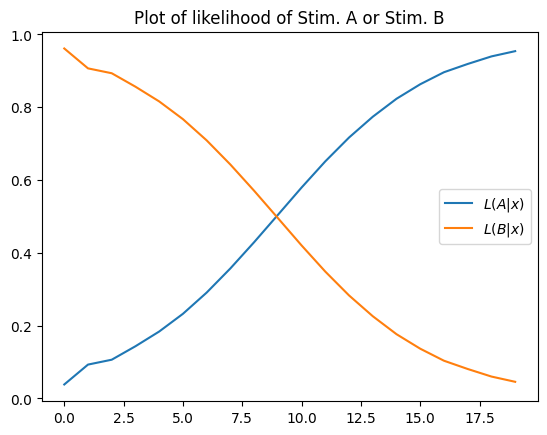

In [ ]:
# plot likelihood
P_x = 1/2 * probA + 1/2 * probB
L_a_x = (0.5 * probA)/P_x
L_b_x = (0.5 * probB)/P_x
plt.plot(L_a_x, label='$L(A|x)$')
plt.plot(L_b_x, label='$L(B|x)$')
plt.legend(loc='center right')
plt.title('Plot of likelihood of Stim. A or Stim. B')